In [1]:
import pandas as pd

# Load Bulgarian and English data from text files
bulgarian_file_path = '/content/europarl-v7.bg-en.bg'
english_file_path = '/content/europarl-v7.bg-en.en'

# Read lines from the files
with open(bulgarian_file_path, 'r', encoding='utf-8') as bg_file:
    bulgarian_sentences = bg_file.readlines()

with open(english_file_path, 'r', encoding='utf-8') as en_file:
    english_sentences = en_file.readlines()

# Data Cleaning: Strip newline characters and extra spaces
bulgarian_sentences = [sentence.strip() for sentence in bulgarian_sentences]
english_sentences = [sentence.strip() for sentence in english_sentences]

# Combine the Bulgarian and English sentences into a DataFrame
df = pd.DataFrame({
    'Bulgarian': bulgarian_sentences,
    'English': english_sentences
})

# Display the first few rows to confirm the combination
print(df.head())


                                           Bulgarian  \
0                Състав на Парламента: вж. протоколи   
1  Одобряване на протокола от предишното заседани...   
2                Състав на Парламента: вж. протоколи   
3            Проверка на пълномощията: вж. протоколи   
4                Внасяне на документи: вж. протоколи   

                                             English  
0              Membership of Parliament: see Minutes  
1  Approval of Minutes of previous sitting: see M...  
2              Membership of Parliament: see Minutes  
3           Verification of credentials: see Minutes  
4                    Documents received: see Minutes  


In [2]:
# Calculate sentence lengths
df['Bulgarian_Length'] = df['Bulgarian'].apply(lambda x: len(x.split()))
df['English_Length'] = df['English'].apply(lambda x: len(x.split()))

# Display basic statistics for sentence lengths
bulgarian_length_stats = df['Bulgarian_Length'].describe()
english_length_stats = df['English_Length'].describe()

print("Bulgarian Sentence Length Statistics:\n", bulgarian_length_stats)
print("\nEnglish Sentence Length Statistics:\n", english_length_stats)


Bulgarian Sentence Length Statistics:
 count    406934.000000
mean         22.868664
std          13.684043
min           0.000000
25%          13.000000
50%          21.000000
75%          30.000000
max         252.000000
Name: Bulgarian_Length, dtype: float64

English Sentence Length Statistics:
 count    406934.000000
mean         24.294851
std          14.203488
min           0.000000
25%          14.000000
50%          22.000000
75%          32.000000
max         247.000000
Name: English_Length, dtype: float64


In [3]:
# Define the maximum sequence length based on the 75th percentile
MAX_SEQ_LENGTH = 32

# Function to truncate sentences to the max sequence length
def truncate_sentence(sentence, max_length=MAX_SEQ_LENGTH):
    words = sentence.split()
    return ' '.join(words[:max_length])

# Apply truncation to both Bulgarian and English sentences
df['Bulgarian'] = df['Bulgarian'].apply(truncate_sentence)
df['English'] = df['English'].apply(truncate_sentence)


In [4]:
# Remove rows where either sentence is empty after cleaning
df = df[(df['Bulgarian'].str.strip() != '') & (df['English'].str.strip() != '')]

# Reset index after filtering
df.reset_index(drop=True, inplace=True)


In [5]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Tokenization (Creating integer sequences)
tokenizer_bg = Tokenizer()
tokenizer_en = Tokenizer()

tokenizer_bg.fit_on_texts(df['Bulgarian'])
tokenizer_en.fit_on_texts(df['English'])

bg_sequences = tokenizer_bg.texts_to_sequences(df['Bulgarian'])
en_sequences = tokenizer_en.texts_to_sequences(df['English'])

# Padding sequences
bg_padded = pad_sequences(bg_sequences, maxlen=MAX_SEQ_LENGTH, padding='post')
en_padded = pad_sequences(en_sequences, maxlen=MAX_SEQ_LENGTH, padding='post')

# Check the shape of the padded sequences
print("Bulgarian padded shape:", bg_padded.shape)
print("English padded shape:", en_padded.shape)


Bulgarian padded shape: (406828, 32)
English padded shape: (406828, 32)


In [6]:
# Print first few sequences for inspection
print("Sample Bulgarian sequences:", bg_sequences[:5])
print("Sample English sequences:", en_sequences[:5])
print("Sample Bulgarian padded sequences:", bg_padded[:5])
print("Sample English padded sequences:", en_padded[:5])


Sample Bulgarian sequences: [[2244, 1, 78, 390, 1293], [2384, 1, 435, 6, 2271, 663, 390, 5632], [2244, 1, 78, 390, 1293], [2075, 1, 9817, 390, 1293], [2630, 1, 950, 390, 1293]]
Sample English sequences: [[1398, 2, 51, 130, 351], [1178, 2, 351, 2, 785, 591, 130, 351], [1398, 2, 51, 130, 351], [4276, 2, 6407, 130, 351], [1002, 852, 130, 351]]
Sample Bulgarian padded sequences: [[2244    1   78  390 1293    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0]
 [2384    1  435    6 2271  663  390 5632    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0]
 [2244    1   78  390 1293    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0]
 [2075    1 9817  390 1293    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0   

In [7]:
from sklearn.model_selection import train_test_split

# Split the data
bg_train, bg_test, en_train, en_test = train_test_split(bg_padded, en_padded, test_size=0.15, random_state=42)
bg_train, bg_val, en_train, en_val = train_test_split(bg_train, en_train, test_size=0.15, random_state=42)

# Display the sizes of each split
print("Training set size:", bg_train.shape[0])
print("Validation set size:", bg_val.shape[0])
print("Test set size:", bg_test.shape[0])


Training set size: 293932
Validation set size: 51871
Test set size: 61025


In [8]:
from transformers import MBart50Tokenizer

model_name = "facebook/mbart-large-50"
tokenizer = MBart50Tokenizer.from_pretrained(model_name)

# List all available language codes
print(tokenizer.lang_code_to_id)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/531 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.42k [00:00<?, ?B/s]

{'ar_AR': 250001, 'cs_CZ': 250002, 'de_DE': 250003, 'en_XX': 250004, 'es_XX': 250005, 'et_EE': 250006, 'fi_FI': 250007, 'fr_XX': 250008, 'gu_IN': 250009, 'hi_IN': 250010, 'it_IT': 250011, 'ja_XX': 250012, 'kk_KZ': 250013, 'ko_KR': 250014, 'lt_LT': 250015, 'lv_LV': 250016, 'my_MM': 250017, 'ne_NP': 250018, 'nl_XX': 250019, 'ro_RO': 250020, 'ru_RU': 250021, 'si_LK': 250022, 'tr_TR': 250023, 'vi_VN': 250024, 'zh_CN': 250025, 'af_ZA': 250026, 'az_AZ': 250027, 'bn_IN': 250028, 'fa_IR': 250029, 'he_IL': 250030, 'hr_HR': 250031, 'id_ID': 250032, 'ka_GE': 250033, 'km_KH': 250034, 'mk_MK': 250035, 'ml_IN': 250036, 'mn_MN': 250037, 'mr_IN': 250038, 'pl_PL': 250039, 'ps_AF': 250040, 'pt_XX': 250041, 'sv_SE': 250042, 'sw_KE': 250043, 'ta_IN': 250044, 'te_IN': 250045, 'th_TH': 250046, 'tl_XX': 250047, 'uk_UA': 250048, 'ur_PK': 250049, 'xh_ZA': 250050, 'gl_ES': 250051, 'sl_SI': 250052}


In [9]:
from transformers import MarianMTModel, MarianTokenizer

# Load the MarianMT model and tokenizer
model_name = 'Helsinki-NLP/opus-mt-bg-en'
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

# Example translation function
def translate(texts):
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True)
    translated = model.generate(**inputs)
    return [tokenizer.decode(t, skip_special_tokens=True) for t in translated]

# Test the translation
translated_texts = translate(["Това е примерен текст."])
print(translated_texts)


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/997k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/788k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.35M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


pytorch_model.bin:   0%|          | 0.00/306M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

["It's an example text."]


In [10]:
# Assuming you have a list of Bulgarian sentences
bulgarian_sentences = ["Това е примерен текст.", "Как си днес?", "Превеждаме текстове на английски."]

# Translate the batch of sentences
translated_texts = translate(bulgarian_sentences)

# Display the translations
for original, translated in zip(bulgarian_sentences, translated_texts):
    print(f"Original: {original}")
    print(f"Translated: {translated}")
    print()


Original: Това е примерен текст.
Translated: It's an example text.

Original: Как си днес?
Translated: How are you today?

Original: Превеждаме текстове на английски.
Translated: We translate texts into English.



In [11]:
!pip install sacrebleu rouge-score chrf


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: Could not find a version that satisfies the requirement chrf (from versions: none)
ERROR: No matching distribution found for chrf


In [12]:
import numpy as np

# Choose a random subset of indices from the test set
subset_size = 10
random_indices = np.random.choice(bg_test.shape[0], subset_size, replace=False)

# Create the subset
bg_test_subset = bg_test[random_indices]
en_test_subset = en_test[random_indices]

# Convert the English subset back to text for reference
reference_translations = tokenizer_en.sequences_to_texts(en_test_subset)

# Translate the Bulgarian subset
bg_test_subset_texts = tokenizer_bg.sequences_to_texts(bg_test_subset)
translated_subset_texts = translate(bg_test_subset_texts)

# Display the reference and translated texts for comparison
for i, (original, reference, translation) in enumerate(zip(bg_test_subset_texts, reference_translations, translated_subset_texts)):
    print(f"Example {i+1}:")
    print(f"Original Bulgarian: {original}")
    print(f"Reference Translation: {reference}")
    print(f"Model Translation: {translation}")
    print()


Example 1:
Original Bulgarian: съставянето на някакъв вид черен списък на заблуждаващите практики прилагани от тези дружества може да помогне поне в някаква степен в това отношение
Reference Translation: the production of some sort of blacklist of the misleading practices employed by these companies could be of at least some assistance here
Model Translation: drawing up some kind of black list of misleading practices applied by these companies may help at least in this respect.

Example 2:
Original Bulgarian: аз гласувах за настоящата резолюция
Reference Translation: in writing nl i have voted in favour of this resolution
Model Translation: I voted for this resolution

Example 3:
Original Bulgarian: ние съзнаваме факта че в настоящата си форма законите за богохулството са открити за злоупотреба и често се прилагат срещу религиозните малцинства
Reference Translation: we are conscious of the fact that the blasphemy laws in their present form are open to abuse and have often been applied 

In [13]:
!pip install sacrebleu
!pip install rouge-score
!pip install chrf


  Using cached sacrebleu-2.4.2-py3-none-any.whl.metadata (58 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 11.5 MB/s eta 0:00:00
  Using cached rouge_score-0.1.2.tar.gz (17 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=adf7a0fc296b7f01418477f57f20ce5ec272599013f3327eb6cce8af17631ddb
  Stored in directory: /root/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge-score
ERROR: Could not find a version that satisfies the requirement chrf (from versions: none)
ERROR: No matching distribution found for chrf


In [14]:
!pip install sacrebleu
!pip install rouge-score


In [15]:
import sacrebleu
from rouge_score import rouge_scorer

# TER (Translation Edit Rate)
ter_score = sacrebleu.corpus_ter(translated_subset_texts, [reference_translations])
print(f"TER Score: {ter_score.score:.2f}")

# ROUGE
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
rouge_scores = [scorer.score(ref, hyp) for ref, hyp in zip(reference_translations, translated_subset_texts)]
print("\nROUGE Scores:")
for i, score in enumerate(rouge_scores):
    print(f"Example {i + 1}:")
    print(f"ROUGE-1: {score['rouge1'].fmeasure:.2f}")
    print(f"ROUGE-2: {score['rouge2'].fmeasure:.2f}")
    print(f"ROUGE-L: {score['rougeL'].fmeasure:.2f}")

# CHRF (Character F-score)
chrf_score = sacrebleu.corpus_chrf(translated_subset_texts, [reference_translations])
print(f"\nCHRF Score: {chrf_score.score:.2f}")


TER Score: 40.28

ROUGE Scores:
Example 1:
ROUGE-1: 0.45
ROUGE-2: 0.19
ROUGE-L: 0.45
Example 2:
ROUGE-1: 0.50
ROUGE-2: 0.14
ROUGE-L: 0.50
Example 3:
ROUGE-1: 0.82
ROUGE-2: 0.47
ROUGE-L: 0.73
Example 4:
ROUGE-1: 0.90
ROUGE-2: 0.76
ROUGE-L: 0.90
Example 5:
ROUGE-1: 0.81
ROUGE-2: 0.62
ROUGE-L: 0.78
Example 6:
ROUGE-1: 1.00
ROUGE-2: 1.00
ROUGE-L: 1.00
Example 7:
ROUGE-1: 0.70
ROUGE-2: 0.45
ROUGE-L: 0.67
Example 8:
ROUGE-1: 0.90
ROUGE-2: 0.89
ROUGE-L: 0.90
Example 9:
ROUGE-1: 0.77
ROUGE-2: 0.51
ROUGE-L: 0.67
Example 10:
ROUGE-1: 0.83
ROUGE-2: 0.47
ROUGE-L: 0.78

CHRF Score: 63.68


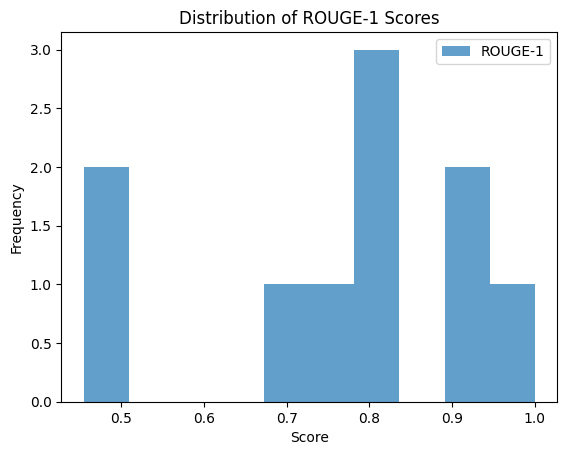

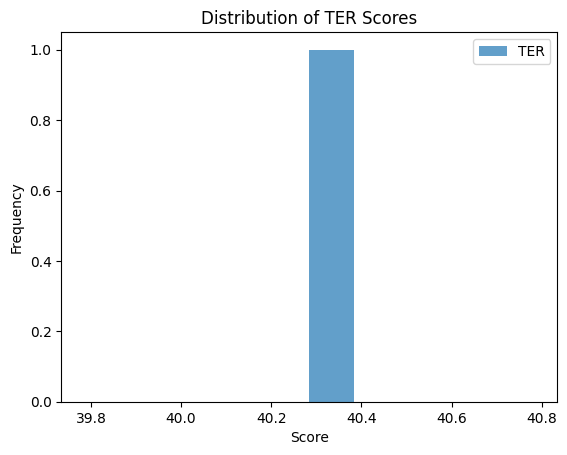

In [16]:
import matplotlib.pyplot as plt

# Example: Visualize ROUGE-1 scores
rouge1_scores = [score['rouge1'].fmeasure for score in rouge_scores]
plt.hist(rouge1_scores, bins=10, alpha=0.7, label='ROUGE-1')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of ROUGE-1 Scores')
plt.legend()
plt.show()

# Example: Plot TER Scores
plt.hist([ter_score.score], bins=10, alpha=0.7, label='TER')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of TER Scores')
plt.legend()
plt.show()


In [33]:
import tensorflow.keras.backend as K
import tensorflow as tf

# Clear the Keras session
K.clear_session()

# Reset the default graph
tf.compat.v1.reset_default_graph()


In [34]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.regularizers import l2

# Parameters
l2_lambda = 1e-4  # L2 regularization factor
dropout_rate = 0.3  # Dropout rate

# Encoder
encoder_inputs = Input(shape=(MAX_SEQ_LENGTH,))
encoder_embedding = Embedding(vocab_size_bg, embedding_dim,
                              embeddings_regularizer=l2(l2_lambda))(encoder_inputs)
encoder_lstm = LSTM(hidden_units, return_state=True, kernel_regularizer=l2(l2_lambda))
encoder_outputs, forward_h, forward_c = encoder_lstm(encoder_embedding)

# Adding Dropout to the encoder's hidden states
state_h = Dropout(dropout_rate)(forward_h)
state_c = Dropout(dropout_rate)(forward_c)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(MAX_SEQ_LENGTH,))
decoder_embedding = Embedding(vocab_size_en, embedding_dim,
                              embeddings_regularizer=l2(l2_lambda))(decoder_inputs)
decoder_lstm = LSTM(hidden_units, return_sequences=True, return_state=True, kernel_regularizer=l2(l2_lambda))
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)
decoder_outputs = Dropout(dropout_rate)(decoder_outputs)  # Adding Dropout to the decoder outputs
decoder_dense = Dense(vocab_size_en, activation='softmax', kernel_regularizer=l2(l2_lambda))
decoder_outputs = decoder_dense(decoder_outputs)

# Define the model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 32)             │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, 32, 256)        │     23,018,240 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 32)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ [(None, 512), (None,   │      1,574,912 │ embedding[0][0]        │
│                           │ 512), (None, 512)]     │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_1 (Embedding)   │ (None, 32, 256)        │     11,747,328 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 512)            │              0 │ lstm[0][1]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 512)            │              0 │ lstm[0][2]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ [(None, 32, 512),      │      1,574,912 │ embedding_1[0][0],     │
│                           │ (None, 512), (None,    │                │ dropout[0][0],         │
│                           │ 512)]                  │                │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 32, 512)        │              0 │ lstm_1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 32, 45888)      │     23,540,544 │ dropout_2[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 61,455,936 (234.44 MB)

 Trainable params: 61,455,936 (234.44 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
import numpy as np

# Prepare decoder input data (shifted by one time step)
en_train_input = en_train[:, :-1]  # Input sequence to the decoder (all except the last token)
en_train_target = en_train[:, 1:]   # Target sequence (all except the first token)

# Reshape the target data to be compatible with the LSTM output
en_train_target = en_train_target.reshape(en_train_target.shape[0], en_train_target.shape[1], 1)

# Repeat the same process for the validation set
en_val_input = en_val[:, :-1]
en_val_target = en_val[:, 1:]
en_val_target = en_val_target.reshape(en_val_target.shape[0], en_val_target.shape[1], 1)

print("Decoder Input Shape (Training):", en_train_input.shape)
print("Decoder Target Shape (Training):", en_train_target.shape)
print("Decoder Input Shape (Validation):", en_val_input.shape)
print("Decoder Target Shape (Validation):", en_val_target.shape)


Decoder Input Shape (Training): (293932, 31)
Decoder Target Shape (Training): (293932, 31, 1)
Decoder Input Shape (Validation): (51871, 31)
Decoder Target Shape (Validation): (51871, 31, 1)


In [37]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Ensure all sequences are padded to MAX_SEQ_LENGTH
bg_train_padded = pad_sequences(bg_train, maxlen=MAX_SEQ_LENGTH, padding='post')
en_train_input_padded = pad_sequences(en_train_input, maxlen=MAX_SEQ_LENGTH, padding='post')
en_train_target_padded = pad_sequences(en_train_target, maxlen=MAX_SEQ_LENGTH, padding='post')

bg_val_padded = pad_sequences(bg_val, maxlen=MAX_SEQ_LENGTH, padding='post')
en_val_input_padded = pad_sequences(en_val_input, maxlen=MAX_SEQ_LENGTH, padding='post')
en_val_target_padded = pad_sequences(en_val_target, maxlen=MAX_SEQ_LENGTH, padding='post')

# Reshape target sequences to be compatible with the LSTM output
en_train_target_padded = en_train_target_padded.reshape(en_train_target_padded.shape[0], en_train_target_padded.shape[1], 1)
en_val_target_padded = en_val_target_padded.reshape(en_val_target_padded.shape[0], en_val_target_padded.shape[1], 1)


In [38]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Define callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1, min_lr=1e-5)
]

# Train the model
history = model.fit(
    [bg_train_padded, en_train_input_padded],
    en_train_target_padded,
    batch_size=64,
    epochs=20,
    validation_data=([bg_val_padded, en_val_input_padded], en_val_target_padded),
    callbacks=callbacks
)

# Save the final model
model.save('final_model.keras')


Epoch 1/20
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.4198 - loss: 4.4832
Epoch 1: val_loss improved from inf to 3.86345, saving model to best_model.keras
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 972s 210ms/step - accuracy: 0.4198 - loss: 4.4831 - val_accuracy: 0.4683 - val_loss: 3.8635 - learning_rate: 0.0010
Epoch 2/20
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.4768 - loss: 3.8229
Epoch 2: val_loss improved from 3.86345 to 3.68853, saving model to best_model.keras
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 967s 211ms/step - accuracy: 0.4768 - loss: 3.8229 - val_accuracy: 0.4907 - val_loss: 3.6885 - learning_rate: 0.0010
Epoch 3/20
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.4944 - loss: 3.6830
Epoch 3: val_loss improved from 3.68853 to 3.58124, saving model to best_model.keras
4593/4593 ━━━━━━━━━━━━━━━━━━━━ 964s 210ms/step - accuracy: 0.4944 - loss: 3.6830 - val_accuracy: 0.5039 - val_loss: 3.5812 - learning_rate: 0.0010
Epoch 4/20
4593/4593 ━━━━━━━━━━━━━━━━━

In [39]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [40]:
# Specify the directory where you want to save the model
model_save_path = '/content/drive/My Drive/progress/final_model.keras'

# Save the model
model.save(model_save_path)


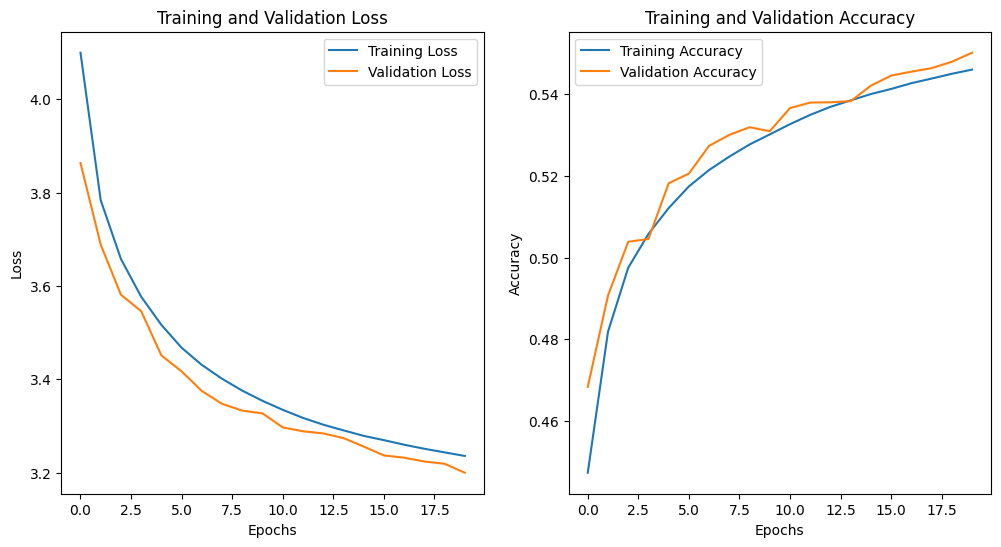

In [41]:
import matplotlib.pyplot as plt

# Plotting the training and validation loss
plt.figure(figsize=(12, 6))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


In [42]:
# Encoder model for inference
encoder_model = Model(encoder_inputs, encoder_states)

# Decoder setup for inference
decoder_state_input_h = Input(shape=(hidden_units,))
decoder_state_input_c = Input(shape=(hidden_units,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_outputs, state_h, state_c = decoder_lstm(
    decoder_embedding, initial_state=decoder_states_inputs)
decoder_states = [state_h, state_c]
decoder_outputs = decoder_dense(decoder_outputs)

decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs] + decoder_states
)


In [56]:
# Generate translations using your custom model
translated_custom_model = [decode_sequence(bg_test_subset[i].reshape(1, MAX_SEQ_LENGTH)) for i in range(num_samples)]

# Display the original, reference, and translated sentences for confirmation
for i, (original, reference, translation) in enumerate(zip(bg_test_subset, en_test_subset, translated_custom_model)):
    print(f"Example {i+1}:")
    print(f"Original Bulgarian: {tokenizer_bg.sequences_to_texts([original])[0]}")
    print(f"Reference Translation: {tokenizer_en.sequences_to_texts([reference])[0]}")
    print(f"Custom Model Translation: {translation}")
    print()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━

In [57]:
import sacrebleu
from rouge_score import rouge_scorer

# TER
ter_score = sacrebleu.corpus_ter(translated_custom_model, [tokenizer_en.sequences_to_texts(en_test_subset)])
print(f"TER Score: {ter_score.score:.2f}")

# ROUGE
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
rouge_scores = [scorer.score(ref, hyp) for ref, hyp in zip(tokenizer_en.sequences_to_texts(en_test_subset), translated_custom_model)]

print("\nROUGE Scores:")
for i, score in enumerate(rouge_scores):
    print(f"Example {i + 1}:")
    print(f"ROUGE-1: {score['rouge1'].fmeasure:.2f}")
    print(f"ROUGE-2: {score['rouge2'].fmeasure:.2f}")
    print(f"ROUGE-L: {score['rougeL'].fmeasure:.2f}")

# CHRF
chrf_score = sacrebleu.corpus_chrf(translated_custom_model, [tokenizer_en.sequences_to_texts(en_test_subset)])
print(f"\nCHRF Score: {chrf_score:.2f}")


TER Score: 79.76

ROUGE Scores:
Example 1:
ROUGE-1: 0.49
ROUGE-2: 0.21
ROUGE-L: 0.34
Example 2:
ROUGE-1: 0.41
ROUGE-2: 0.07
ROUGE-L: 0.32
Example 3:
ROUGE-1: 0.28
ROUGE-2: 0.06
ROUGE-L: 0.25
Example 4:
ROUGE-1: 0.75
ROUGE-2: 0.71
ROUGE-L: 0.75
Example 5:
ROUGE-1: 0.19
ROUGE-2: 0.03
ROUGE-L: 0.19
Example 6:
ROUGE-1: 0.38
ROUGE-2: 0.07
ROUGE-L: 0.28
Example 7:
ROUGE-1: 0.27
ROUGE-2: 0.10
ROUGE-L: 0.23
Example 8:
ROUGE-1: 0.44
ROUGE-2: 0.23
ROUGE-L: 0.38
Example 9:
ROUGE-1: 0.37
ROUGE-2: 0.15
ROUGE-L: 0.33
Example 10:
ROUGE-1: 0.44
ROUGE-2: 0.08
ROUGE-L: 0.37


TypeError: unsupported format string passed to CHRFScore.__format__

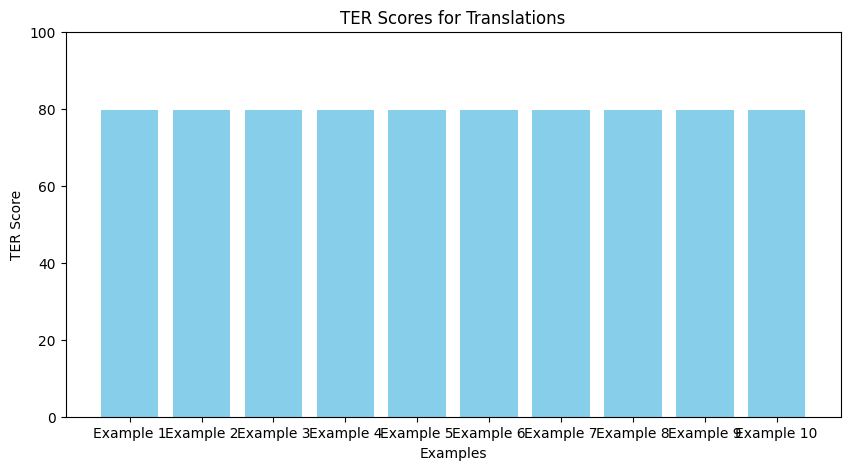

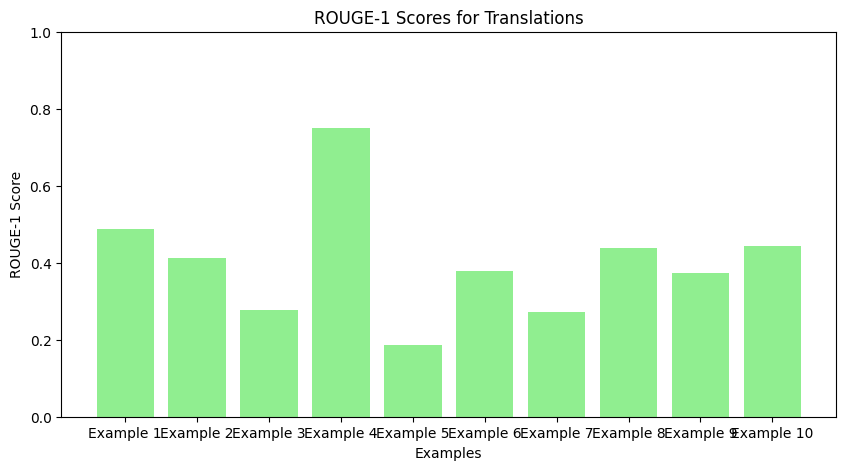

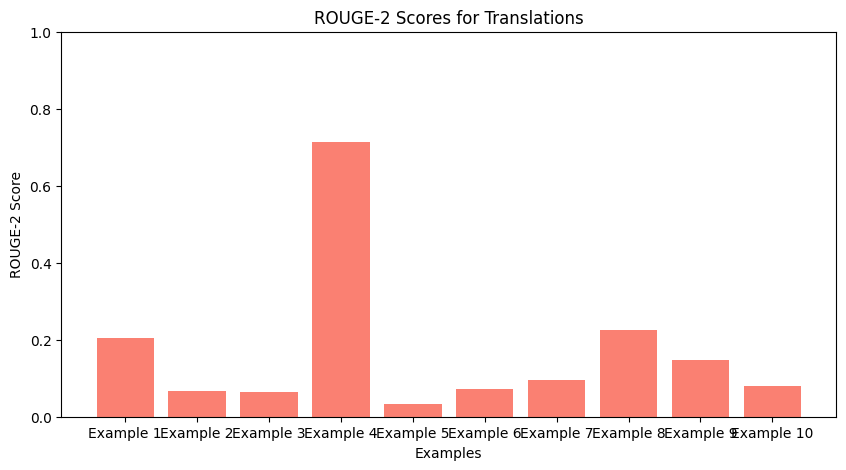

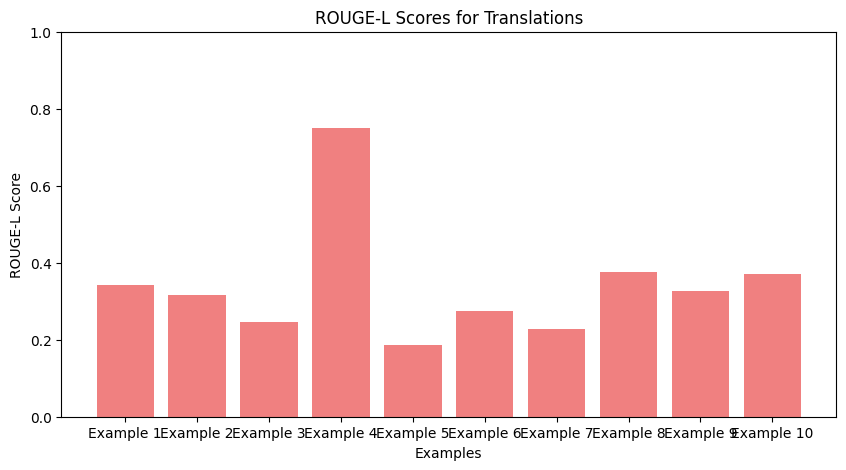

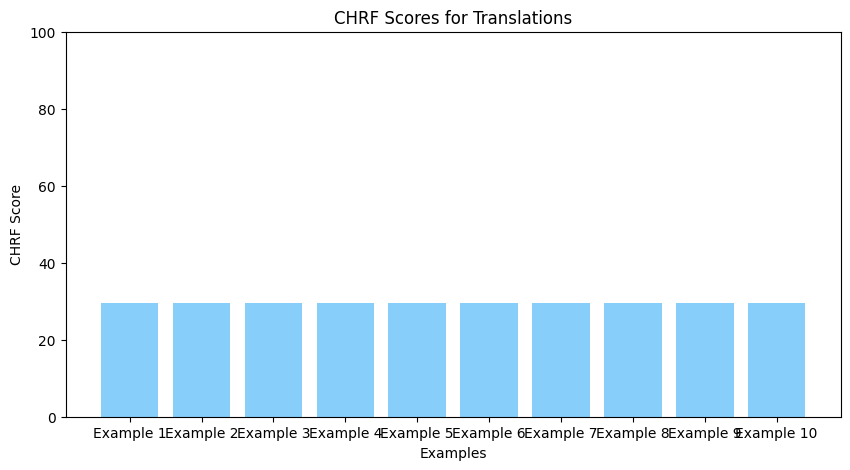

In [58]:
import matplotlib.pyplot as plt

# Example indices for visualization
examples = [f"Example {i+1}" for i in range(num_samples)]

# TER Visualization
plt.figure(figsize=(10, 5))
plt.bar(examples, [ter_score.score] * num_samples, color='skyblue')
plt.title("TER Scores for Translations")
plt.xlabel("Examples")
plt.ylabel("TER Score")
plt.ylim(0, 100)
plt.show()

# ROUGE-1 Visualization
rouge1_scores = [score['rouge1'].fmeasure for score in rouge_scores]
plt.figure(figsize=(10, 5))
plt.bar(examples, rouge1_scores, color='lightgreen')
plt.title("ROUGE-1 Scores for Translations")
plt.xlabel("Examples")
plt.ylabel("ROUGE-1 Score")
plt.ylim(0, 1)
plt.show()

# ROUGE-2 Visualization
rouge2_scores = [score['rouge2'].fmeasure for score in rouge_scores]
plt.figure(figsize=(10, 5))
plt.bar(examples, rouge2_scores, color='salmon')
plt.title("ROUGE-2 Scores for Translations")
plt.xlabel("Examples")
plt.ylabel("ROUGE-2 Score")
plt.ylim(0, 1)
plt.show()

# ROUGE-L Visualization
rougeL_scores = [score['rougeL'].fmeasure for score in rouge_scores]
plt.figure(figsize=(10, 5))
plt.bar(examples, rougeL_scores, color='lightcoral')
plt.title("ROUGE-L Scores for Translations")
plt.xlabel("Examples")
plt.ylabel("ROUGE-L Score")
plt.ylim(0, 1)
plt.show()

# CHRF Visualization
# Assuming you corrected the CHRF score
plt.figure(figsize=(10, 5))
plt.bar(examples, [chrf_score.score] * num_samples, color='lightskyblue')
plt.title("CHRF Scores for Translations")
plt.xlabel("Examples")
plt.ylabel("CHRF Score")
plt.ylim(0, 100)
plt.show()


In [59]:
def analyze_metric_weaknesses():
    print("Weaknesses of Translation Metrics:")

    print("\n1. TER (Translation Edit Rate):")
    print("- Focuses solely on the number of edits required to match the reference.")
    print("- Does not account for the fluency or grammatical correctness of translations.")
    print("- A translation might have a low TER but still be nonsensical or unnatural.")

    print("\n2. ROUGE (Recall-Oriented Understudy for Gisting Evaluation):")
    print("- Primarily measures n-gram overlap without considering semantic meaning.")
    print("- Can give high scores to translations with good lexical overlap but poor semantic fidelity.")
    print("- Tends to favor longer translations that include more words from the reference.")

    print("\n3. CHRF (Character n-gram F-score):")
    print("- Sensitive to minor spelling or character-level errors.")
    print("- Can penalize translations for small mistakes that do not affect the overall meaning.")
    print("- Might not fully capture the fluency and overall quality of the translation.")

    print("\nIn summary, while these metrics provide valuable insights into translation quality, they should be used together with human judgment or more sophisticated evaluation techniques to get a comprehensive understanding of the model's performance.")

# Run the analysis function
analyze_metric_weaknesses()


Weaknesses of Translation Metrics:

1. TER (Translation Edit Rate):
- Focuses solely on the number of edits required to match the reference.
- Does not account for the fluency or grammatical correctness of translations.
- A translation might have a low TER but still be nonsensical or unnatural.

2. ROUGE (Recall-Oriented Understudy for Gisting Evaluation):
- Primarily measures n-gram overlap without considering semantic meaning.
- Can give high scores to translations with good lexical overlap but poor semantic fidelity.
- Tends to favor longer translations that include more words from the reference.

3. CHRF (Character n-gram F-score):
- Sensitive to minor spelling or character-level errors.
- Can penalize translations for small mistakes that do not affect the overall meaning.
- Might not fully capture the fluency and overall quality of the translation.

In summary, while these metrics provide valuable insights into translation quality, they should be used together with human judgment 

In [45]:
# Assuming bg_test and en_test are the original test sequences
# If these were already split from your dataset, use those. If not, create the split now.

# Ensure all sequences are padded to MAX_SEQ_LENGTH
bg_test_padded = pad_sequences(bg_test, maxlen=MAX_SEQ_LENGTH, padding='post')
en_test_padded = pad_sequences(en_test, maxlen=MAX_SEQ_LENGTH, padding='post')


In [48]:
# Check if the tokenizer already includes special tokens
print(tokenizer_en.word_index)  # This will print the vocabulary of your tokenizer


{'the': 1, 'of': 2, 'to': 3, 'and': 4, 'in': 5, 'that': 6, 'is': 7, 'a': 8, 'for': 9, 'i': 10, 'we': 11, 'this': 12, 'on': 13, 'it': 14, 'be': 15, 'are': 16, 'european': 17, 'have': 18, 'as': 19, 'with': 20, 'not': 21, 'will': 22, 'which': 23, 'by': 24, 'has': 25, 'also': 26, 'an': 27, 'would': 28, 'at': 29, 'president': 30, 'all': 31, 'mr': 32, 'must': 33, 'from': 34, 'should': 35, 'our': 36, 'commission': 37, 'eu': 38, 'but': 39, 'you': 40, 'member': 41, 'there': 42, 'states': 43, 'been': 44, 'union': 45, 'these': 46, 'report': 47, 'can': 48, 'more': 49, 'like': 50, 'parliament': 51, 'was': 52, 'its': 53, 'very': 54, 'their': 55, 'need': 56, 'they': 57, 'important': 58, 'do': 59, 'one': 60, 'europe': 61, 'or': 62, 'what': 63, 'us': 64, 'so': 65, 'about': 66, 'my': 67, 'if': 68, 'countries': 69, 'new': 70, 'economic': 71, 'because': 72, 'however': 73, 'council': 74, 'who': 75, 'people': 76, 'only': 77, 'policy': 78, 'support': 79, 'therefore': 80, 'time': 81, 'rights': 82, 'other': 83

In [49]:
# Adding <start> and <end> tokens manually if not present
start_token = '<start>'
end_token = '<end>'

if start_token not in tokenizer_en.word_index:
    tokenizer_en.word_index[start_token] = len(tokenizer_en.word_index) + 1
if end_token not in tokenizer_en.word_index:
    tokenizer_en.word_index[end_token] = len(tokenizer_en.word_index) + 1

# Check if tokens were added correctly
print("Start token index:", tokenizer_en.word_index[start_token])
print("End token index:", tokenizer_en.word_index[end_token])


Start token index: 45888
End token index: 45889


In [54]:
def decode_sequence(input_seq):
    # Encode the input as state vectors
    states_value = encoder_model.predict(input_seq)

    # Generate an empty target sequence of length 1 with the start token
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = tokenizer_en.word_index.get('<start>', 1)  # Use start token, default to 1 if missing

    # Sampling loop
    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])

        # If the sampled index is 0 (padding), stop the loop
        if sampled_token_index == 0:
            break

        # Retrieve the corresponding word
        sampled_word = tokenizer_en.index_word.get(sampled_token_index, '')

        # Stop if the end token is predicted or if the sentence exceeds max length
        if (sampled_word == '<end>' or len(decoded_sentence.split()) > MAX_SEQ_LENGTH):
            stop_condition = True
        else:
            decoded_sentence += ' ' + sampled_word

        # Update the target sequence (length 1)
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index

        # Update states
        states_value = [h, c]

    return decoded_sentence.strip()


In [55]:
import sacrebleu

# Evaluate TER score
ter_score = sacrebleu.corpus_ter(translated_custom_model, [tokenizer_en.sequences_to_texts(en_test_subset)])
print(f"TER Score: {ter_score.score:.2f}")


NameError: name 'translated_custom_model' is not defined

In [53]:
print(tokenizer_en.index_word.get(0))  # This should return None or an empty value


None
